# Accuracy verification: best-of-n on AIME (Llama-3.2-1B-Instruct)

Reads the best-of-n completion JSONL files for **vllm** (baseline) and **ours**
from
`data/meta-llama/Llama-3.2-1B-Instruct/aimo-validation-aime/accuracy_verify/`,
computes accuracy for each beam budget `n`, and reports it as a table and a
grouped bar chart.

- Model: `meta-llama/Llama-3.2-1B-Instruct`
- Dataset: `aimo-validation-aime` (90 problems)
- Approach: best-of-n

Grading uses the repo's `sal/utils/math.py`: `memoized_canonical_form`
normalizes both the prediction and the gold `answer` to a sympy canonical form,
and the two are compared for symbolic equivalence (`extract_answer` first pulls
the boxed answer out of a completion).

**Correctness criterion:** kernel optimizations change floating-point results,
so `ours` will not be row-by-row identical to `vllm`. AIME is only 90 problems
and very hard for a 1B model — expect low accuracy and noise-dominated gaps.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Repo layout: this notebook lives in <repo>/scripts/, package is <repo>/src/sal
REPO = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

# Grading primitives from the repo (sal/utils/math.py + the answer parser).
from sal.utils.math import memoized_canonical_form
from sal.utils.qwen_math_parser import extract_answer

# MODEL = "meta-llama/Llama-3.2-1B-Instruct"
MODEL = "Qwen/QWen2.5-1.5B-Instruct"
# DATASET = "aimo-validation-aime"
DATASET = "MATH-500"
METHODS = ["vllm", "ours"]

# All best_of_n_completions_{vllm,ours}_n*.jsonl files live in this folder.
BON_DIR = REPO / "data" / MODEL / DATASET / "accuracy_verify"

FIG_DIR = REPO / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("repo    :", REPO)
print("bon dir :", BON_DIR, "(exists)" if BON_DIR.is_dir() else "(MISSING)")

repo    : .
bon dir : ./data/Qwen/QWen2.5-1.5B-Instruct/MATH-500/accuracy_verify (exists)


In [2]:
# --- grading helpers ---------------------------------------------------

def canon(s):
    """Canonical (symbolically-normalized) form, with a safe fallback."""
    try:
        return memoized_canonical_form(str(s))
    except Exception:
        return str(s).strip()


def is_correct(pred_text, gold_canon):
    """True if the answer extracted from `pred_text` matches the gold answer.

    `pred_text` may be a full completion or an already-boxed string;
    extract_answer handles both.
    """
    if pred_text is None or pred_text == "":
        return False
    pred_ans = extract_answer(str(pred_text), "math")
    if pred_ans is None or pred_ans == "":
        return False
    return canon(pred_ans) == gold_canon


def parse_name(path):
    """best_of_n_completions_<method>_n<N>.jsonl -> (method, N) or None."""
    m = re.match(r"best_of_n_completions_(\w+?)_n(\d+)\.jsonl$", path.name)
    return (m.group(1), int(m.group(2))) if m else None


def prm_was_used(data):
    """A run is PRM-scored if any aggregated score is non-zero. PRM-disabled
    runs write placeholder scores of 0.0 for every beam."""
    return any(v for d in data for v in d.get("agg_scores", []))

In [3]:
# --- 1. discover the vllm + ours json files ----------------------------
files = []
if BON_DIR.is_dir():
    for p in sorted(BON_DIR.glob("best_of_n_completions_*_n*.jsonl")):
        parsed = parse_name(p)
        if parsed and parsed[0] in METHODS:
            files.append((parsed[0], parsed[1], p))

files.sort(key=lambda t: (t[0], t[1]))
for method, n, p in files:
    print(f"  {method:5s}  n={n:<4d}  {p.name}")
print(f"\n{len(files)} files to evaluate")
if not files:
    print(f"\n[!] No best-of-n files in {BON_DIR}")

  ours   n=2     best_of_n_completions_ours_n2.jsonl
  ours   n=4     best_of_n_completions_ours_n4.jsonl
  ours   n=8     best_of_n_completions_ours_n8.jsonl
  ours   n=16    best_of_n_completions_ours_n16.jsonl
  ours   n=32    best_of_n_completions_ours_n32.jsonl
  ours   n=64    best_of_n_completions_ours_n64.jsonl
  vllm   n=2     best_of_n_completions_vllm_n2.jsonl
  vllm   n=4     best_of_n_completions_vllm_n4.jsonl
  vllm   n=8     best_of_n_completions_vllm_n8.jsonl
  vllm   n=16    best_of_n_completions_vllm_n16.jsonl
  vllm   n=32    best_of_n_completions_vllm_n32.jsonl
  vllm   n=64    best_of_n_completions_vllm_n64.jsonl

12 files to evaluate


In [4]:
# --- 2. compute accuracy for each beam setting -------------------------
# Three predictions, all already present in the JSONL:
#   pred            -> best-of-n: PRM-argmax winner over all n completions
#   pred_weighted@n -> PRM score-weighted vote
#   pred_maj@n      -> plain majority vote (does NOT need the PRM)
rows = []
for method, n, path in files:
    with open(path) as fh:
        data = [json.loads(line) for line in fh]

    gold = [canon(d["answer"]) for d in data]
    n_problems = len(data)
    prm_ok = prm_was_used(data)

    bon = sum(is_correct(d["pred"], g) for d, g in zip(data, gold))

    wcol, mcol = f"pred_weighted@{n}", f"pred_maj@{n}"
    weighted = (sum(is_correct(d.get(wcol), g) for d, g in zip(data, gold))
                if wcol in data[0] else None)
    majority = (sum(is_correct(d.get(mcol), g) for d, g in zip(data, gold))
                if mcol in data[0] else None)

    rows.append({
        "method": method,
        "n": n,
        "problems": n_problems,
        "prm_scored": prm_ok,
        "best_of_n": bon / n_problems,
        "weighted": weighted / n_problems if weighted is not None else None,
        "majority": majority / n_problems if majority is not None else None,
    })
    flag = "" if prm_ok else "  [PRM DISABLED -> best_of_n/weighted invalid]"
    print(f"{method:5s} n={n:<4d}  best-of-n={bon}/{n_problems}  "
          f"majority={majority}/{n_problems}{flag}")

df = pd.DataFrame(rows).sort_values(["method", "n"]).reset_index(drop=True)
df

ours  n=2     best-of-n=239/500  majority=196/500
ours  n=4     best-of-n=260/500  majority=224/500
ours  n=8     best-of-n=283/500  majority=264/500
ours  n=16    best-of-n=288/500  majority=285/500
ours  n=32    best-of-n=307/500  majority=297/500
ours  n=64    best-of-n=307/500  majority=309/500
vllm  n=2     best-of-n=232/500  majority=195/500
vllm  n=4     best-of-n=274/500  majority=245/500
vllm  n=8     best-of-n=290/500  majority=266/500
vllm  n=16    best-of-n=294/500  majority=285/500
vllm  n=32    best-of-n=300/500  majority=300/500
vllm  n=64    best-of-n=306/500  majority=300/500


,method,n,problems,prm_scored,best_of_n,weighted,majority
0,ours,2,500,True,0.478,0.478,0.392
1,ours,4,500,True,0.520,0.536,0.448
2,ours,8,500,True,0.566,0.606,0.528
3,ours,16,500,True,0.576,0.624,0.570
4,ours,32,500,True,0.614,0.656,0.594
5,ours,64,500,True,0.614,0.670,0.618
6,vllm,2,500,True,0.464,0.464,0.390
7,vllm,4,500,True,0.548,0.558,0.490
8,vllm,8,500,True,0.580,0.608,0.532
9,vllm,16,500,True,0.588,0.628,0.570


In [21]:
# --- 3a. report: vllm vs ours table ------------------------------------
if not df.empty:
    # best-of-n is only trustworthy when the PRM ran; otherwise fall back to
    # majority vote as the headline metric.
    METRIC = "best_of_n" if df["prm_scored"].all() else "majority"
    if METRIC != "best_of_n":
        print("[!] Some files are PRM-disabled (placeholder scores).")
        print("    Reporting MAJORITY vote instead of best-of-n.\n")

    pivot = df.pivot(index="n", columns="method", values=METRIC)
    pivot = pivot.reindex(columns=[m for m in METHODS if m in pivot.columns])
    if {"vllm", "ours"}.issubset(pivot.columns):
        pivot["delta (ours-vllm)"] = pivot["ours"] - pivot["vllm"]

    print(f"AIME accuracy ({METRIC}, %)  -  Llama-3.2-1B-Instruct\n")
    print((pivot * 100).round(2).to_string())
else:
    METRIC = "best_of_n"
    print("No data to report.")

AIME accuracy (best_of_n, %)  -  Llama-3.2-1B-Instruct

method  vllm  ours  delta (ours-vllm)
n                                    
2       46.4  47.8                1.4
4       54.8  52.0               -2.8
8       58.0  56.6               -1.4
16      58.8  57.6               -1.2
32      60.0  61.4                1.4
64      61.2  61.4                0.2


saved: ./figures/accuracy_verify.png


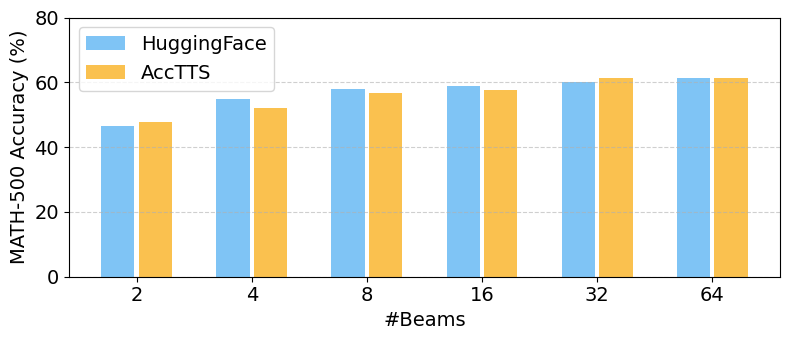

In [48]:
# --- 3b. report: grouped bar chart -------------------------------------
# ================= FIGURE STYLE CONTROLS (tweak freely) =================
FIG_SIZE        = (8, 3.5)     # figure size in inches (width, height)
FONTSIZE_LABEL  = 14         # x / y axis label font size
FONTSIZE_LEGEND = 14         # legend font size
FONTSIZE_TICK   = 14         # axis tick (values) font size
BAR_WIDTH       = 0.30       # width of each individual bar
INTRA_GAP       = 0.04       # gap between the two bars within one group
INTER_GAP       = 0.40       # gap between adjacent beam-count groups
Y_LIM           = (0, 80)   # y-axis range (min, max) in %; set None for auto
# ========================================================================

# per-method bar color and legend label
colors = {"vllm": "#7fc4f5", "ours": "#fac14f"}
LEGEND_LABELS = {"vllm": "HuggingFace", "ours": "AccTTS"}

if not df.empty:
    beams = sorted(df["n"].unique())
    # group stride = total span of one group (2 bars + intra gap) + inter gap
    group_w = 2 * BAR_WIDTH + INTRA_GAP
    stride = group_w + INTER_GAP
    centers = [i * stride for i in range(len(beams))]
    off = (BAR_WIDTH + INTRA_GAP) / 2   # each bar's offset from group center

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    for sign, method in zip((-1, +1), METHODS):
        sub = df[df["method"] == method].set_index("n")
        vals = [sub.loc[b, METRIC] * 100 if b in sub.index else 0.0
                for b in beams]
        xs = [c + sign * off for c in centers]
        ax.bar(xs, vals, width=BAR_WIDTH, label=LEGEND_LABELS.get(method, method),
               color=colors.get(method))

    ax.set_xticks(centers)
    ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.6)
    ax.set_xticklabels([str(b) for b in beams], fontsize=FONTSIZE_TICK)
    ax.tick_params(axis="y", labelsize=FONTSIZE_TICK)
    ax.set_xlabel("#Beams", fontsize=FONTSIZE_LABEL)
    ax.set_ylabel("MATH-500 Accuracy (%)", fontsize=FONTSIZE_LABEL)
    if Y_LIM is not None:
        ax.set_ylim(*Y_LIM)
    ax.legend(fontsize=FONTSIZE_LEGEND)
    fig.tight_layout()

    out_png = FIG_DIR / "accuracy_verify.png"
    fig.savefig(out_png, dpi=300)
    print("saved:", out_png)
    plt.show()
else:
    print("No data to plot.")

## Multi-round accuracy verification

These cells read the seed-suffixed best-of-n outputs produced by `scripts/run_vllm_accuracy_verify_n163264.sh`, compute per-seed accuracy for baseline (`vllm`) and AccTTS (`ours`), aggregate accuracy across completed seeds, and plot mean accuracy with error bars.

Expected input files live under `data/meta-llama/Llama-3.2-1B-Instruct/aimo-validation-aime/accuracy_verify/` and are named like `best_of_n_completions_vllm_seed0_n2.jsonl` and `best_of_n_completions_ours_seed0_n2.jsonl`.


In [5]:
# --- 4. multi-round result config -------------------------------------
import math
from pathlib import Path

MR_MODEL = "meta-llama/Llama-3.2-1B-Instruct"
MR_DATASET_SHORT = "MATH-500"
MR_DATA_DIR = REPO / "data" / MR_MODEL / MR_DATASET_SHORT
MR_OUT_DIR = MR_DATA_DIR / "accuracy_verify"

MR_BEAMS = [2, 4, 8, 16, 32, 64]
MR_SEEDS = [0, 1, 2, 3, 4]
MR_METHODS = ["vllm", "ours"]
MR_METHOD_LABELS = {"vllm": "HuggingFace", "ours": "AccTTS"}
MR_COLORS = {"vllm": "#7fc4f5", "ours": "#fac14f"}
MR_METRIC = "best_of_n"  # PRM-selected `pred`; valid when prm_scored=True.

MR_PER_SEED_CSV = MR_OUT_DIR / "accuracy_verify_multi_round_per_seed.csv"
MR_SUMMARY_CSV = MR_OUT_DIR / "accuracy_verify_multi_round_summary.csv"
MR_PLOT_PATH = FIG_DIR / "accuracy_verify_aime_llama1b_multi_round.png"

print("result dir:", MR_OUT_DIR, "(exists)" if MR_OUT_DIR.is_dir() else "(MISSING)")
print("beams     :", MR_BEAMS)
print("seeds     :", MR_SEEDS)
print("methods   :", {m: MR_METHOD_LABELS[m] for m in MR_METHODS})


result dir: ./data/meta-llama/Llama-3.2-1B-Instruct/MATH-500/accuracy_verify (exists)
beams     : [2, 4, 8, 16, 32, 64]
seeds     : [0, 1, 2, 3, 4]
methods   : {'vllm': 'HuggingFace', 'ours': 'AccTTS'}


In [ ]:
# --- 5. read generated baseline + AccTTS seed files -------------------
def parse_multi_round_name(path):
    m = re.match(r"best_of_n_completions_(vllm|ours)_seed(\d+)_n(\d+)\.jsonl$", path.name)
    if not m:
        return None
    return m.group(1), int(m.group(2)), int(m.group(3))

mr_files = []
if MR_OUT_DIR.is_dir():
    for path in sorted(MR_OUT_DIR.glob("best_of_n_completions_*_seed*_n*.jsonl")):
        parsed = parse_multi_round_name(path)
        if parsed is None:
            continue
        method, seed, n = parsed
        if method in MR_METHODS and seed in MR_SEEDS and n in MR_BEAMS:
            mr_files.append({"method": method, "seed": seed, "n": n, "path": path})

mr_file_df = pd.DataFrame(mr_files).sort_values(["seed", "n", "method"]).reset_index(drop=True) if mr_files else pd.DataFrame(columns=["method", "seed", "n", "path"])

expected = {(method, seed, n) for method in MR_METHODS for seed in MR_SEEDS for n in MR_BEAMS}
found = {(r["method"], r["seed"], r["n"]) for r in mr_files}
missing = sorted(expected - found, key=lambda x: (x[1], x[2], x[0]))

print(f"found {len(mr_file_df)} / {len(expected)} expected seed files")
if not mr_file_df.empty:
    display(mr_file_df.assign(path=mr_file_df["path"].map(lambda p: p.name)))

if missing:
    print("\nMissing files (usually still running or not launched yet):")
    for method, seed, n in missing[:24]:
        print(f"  {MR_METHOD_LABELS[method]:10s} seed={seed} n={n}")
    if len(missing) > 24:
        print(f"  ... {len(missing) - 24} more")


In [ ]:
# --- 6. calculate per-seed accuracy and aggregate error bars ----------
def load_jsonl(path):
    with open(path) as fh:
        return [json.loads(line) for line in fh]

rows = []
summary = pd.DataFrame()
delta_summary = pd.DataFrame()
for rec in mr_files:
    method, seed, n, path = rec["method"], rec["seed"], rec["n"], rec["path"]
    data = load_jsonl(path)
    if not data:
        continue

    gold = [canon(d.get("answer", "")) for d in data]
    best_of_n_correct = sum(is_correct(d.get("pred"), g) for d, g in zip(data, gold))

    weighted_col = f"pred_weighted@{n}"
    majority_col = f"pred_maj@{n}"
    weighted_correct = (
        sum(is_correct(d.get(weighted_col), g) for d, g in zip(data, gold))
        if weighted_col in data[0]
        else None
    )
    majority_correct = (
        sum(is_correct(d.get(majority_col), g) for d, g in zip(data, gold))
        if majority_col in data[0]
        else None
    )

    rows.append({
        "method": method,
        "method_label": MR_METHOD_LABELS[method],
        "seed": seed,
        "n": n,
        "problems": len(data),
        "prm_scored": prm_was_used(data),
        "best_of_n_correct": best_of_n_correct,
        "best_of_n": best_of_n_correct / len(data),
        "weighted_correct": weighted_correct,
        "weighted": weighted_correct / len(data) if weighted_correct is not None else None,
        "majority_correct": majority_correct,
        "majority": majority_correct / len(data) if majority_correct is not None else None,
        "path": path.name,
    })

mr_df = pd.DataFrame(rows).sort_values(["seed", "n", "method"]).reset_index(drop=True) if rows else pd.DataFrame()

if mr_df.empty:
    print(f"No generated multi-round result files found in {MR_OUT_DIR}")
else:
    if not mr_df["prm_scored"].all():
        print("[!] Some runs look PRM-disabled; `best_of_n` accuracy is not valid for those rows.")

    per_seed = mr_df.pivot_table(index=["seed", "n"], columns="method", values=MR_METRIC, aggfunc="first")
    per_seed = per_seed.rename(columns=MR_METHOD_LABELS)
    if {"HuggingFace", "AccTTS"}.issubset(per_seed.columns):
        per_seed["AccTTS-HuggingFace"] = per_seed["AccTTS"] - per_seed["HuggingFace"]

    print("Per-seed AIME accuracy (%)")
    print((per_seed * 100).round(2).to_string())

    summary = (
        mr_df.groupby(["method", "method_label", "n"])[MR_METRIC]
        .agg(mean="mean", std="std", rounds="count")
        .reset_index()
    )
    summary["sem"] = summary["std"] / summary["rounds"].pow(0.5)
    summary.loc[summary["rounds"] <= 1, ["std", "sem"]] = 0.0

    summary_report = summary.copy()
    for col in ["mean", "std", "sem"]:
        summary_report[f"{col}_%"] = summary_report[col] * 100
    summary_report = summary_report[["method_label", "n", "rounds", "mean_%", "std_%", "sem_%"]]

    print("\nAverage across completed seeds (%)")
    print(summary_report.round(2).to_string(index=False))

    paired = mr_df.pivot_table(index=["seed", "n"], columns="method", values=MR_METRIC, aggfunc="first")
    if {"vllm", "ours"}.issubset(paired.columns):
        delta = (paired["ours"] - paired["vllm"]).dropna().rename("delta")
        if not delta.empty:
            delta_summary = delta.groupby(level="n").agg(mean="mean", std="std", rounds="count").reset_index()
            delta_summary["sem"] = delta_summary["std"] / delta_summary["rounds"].pow(0.5)
            delta_summary.loc[delta_summary["rounds"] <= 1, ["std", "sem"]] = 0.0
            print("\nPaired delta AccTTS-HuggingFace (%)")
            shown = delta_summary.assign(
                mean_pct=delta_summary["mean"] * 100,
                std_pct=delta_summary["std"] * 100,
                sem_pct=delta_summary["sem"] * 100,
            )[["n", "rounds", "mean_pct", "std_pct", "sem_pct"]]
            print(shown.round(2).to_string(index=False))

    mr_df.to_csv(MR_PER_SEED_CSV, index=False)
    summary.to_csv(MR_SUMMARY_CSV, index=False)
    print("\nsaved:", MR_PER_SEED_CSV)
    print("saved:", MR_SUMMARY_CSV)


saved: ./figures/accuracy_verify_aime_llama1b_multi_round.png


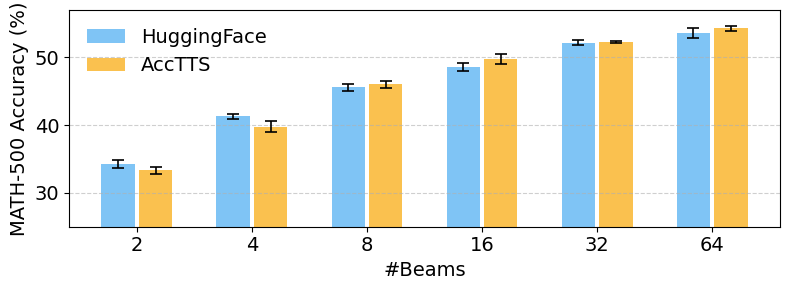

In [14]:
# --- 7. plot mean accuracy bars with seed error bars ------------------
# Error bars are standard error of the mean (SEM) across completed seeds.
if "summary" not in globals() or summary.empty:
    print("No multi-round accuracy summary to plot.")
else:
    beams = [b for b in MR_BEAMS if b in set(summary["n"])]
    bar_width = 0.30
    intra_gap = 0.04
    inter_gap = 0.40
    group_w = len(MR_METHODS) * bar_width + (len(MR_METHODS) - 1) * intra_gap
    stride = group_w + inter_gap
    centers = [i * stride for i in range(len(beams))]

    fig, ax = plt.subplots(figsize=(8, 3))
    for j, method in enumerate(MR_METHODS):
        sub = summary[summary["method"] == method].set_index("n")
        offset = (j - (len(MR_METHODS) - 1) / 2) * (bar_width + intra_gap)
        xs = [c + offset for c in centers]
        vals = [sub.loc[b, "mean"] * 100 if b in sub.index else float("nan") for b in beams]
        errs = [sub.loc[b, "sem"] * 100 if b in sub.index else 0.0 for b in beams]
        ax.bar(
            xs,
            vals,
            yerr=errs,
            capsize=4,
            error_kw={"elinewidth": 1.2, "capthick": 1.2},
            width=bar_width,
            label=MR_METHOD_LABELS[method],
            color=MR_COLORS[method],
        )

    ax.set_xticks(centers)
    ax.set_xticklabels([str(b) for b in beams], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.set_ylim(25, 57)
    ax.set_xlabel("#Beams", fontsize=14)
    ax.set_ylabel("MATH-500 Accuracy (%)", fontsize=14)
    ax.legend(fontsize=14, frameon=False)
    fig.tight_layout()
    fig.savefig(MR_PLOT_PATH, dpi=300)
    print("saved:", MR_PLOT_PATH)
    plt.show()
